# 3. Which quantity am I measuring?

Notebook 02 estimated the mutual information between one instant of $X$ and one
instant of $Y$. All the information sat in that instant, so
$I(X_{t=i};Y_{t=j})$ is zero unless $i=j$, and there was no notion of time at
all. Once we have time as an axis, $I(X_{t=i};Y_{t=j})$ is almost certainly
non-zero for neighbouring points at least. The instantaneous value then answers
one aspect only, and it becomes one member of a larger family whose other
members answer different questions about the same recording.

The nice thing is that all of them run through the same estimator machinery
whose workings we now know. What changes between them is which signals go in
and at which time offsets. Those offsets decide the units you get back, and in
practice how much the run costs.

We'll show three members of the family first, then we'll build the rest.

## Imports

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import neural_mi as nmi
from neural_mi import Conditional
from neural_mi.generators import SharedLatentGaussian

nmi.set_verbosity('ERROR')

## Cost knobs

In [2]:
# --- Cost knobs -----------------------------------------------------------
# Safe to reduce. These cost precision and leave the conclusions standing.

T            = 10_000        # samples drawn from the generator
WINDOW_SWEEP = [1, 2, 3, 5, 10, 20, 30]   # window sizes for the extensive curve
HALF_WIDTH   = 10            # half-width L of X's two-sided window, for mi_rate
H_RATE       = 8             # history of Y conditioned on, for mi_rate
W_BLOCK      = 5             # the single window used in section 4's table
N_EPOCHS     = 200

# Load-bearing.

N_SEEDS = 3
# Section 4's result is the spread across seeds. At one seed there is no
# spread column across different seeds and the section makes no sense.

K = 8
# History length for every temporal quantity. Moving it changes which exact
# value each estimate is graded against.

SEED = 0

N_WORKERS = 8
# How many runs go at once. Set it to your core count: every repeat below is an
# independent job and the library dispatches them to a pool.

# Quick pass: drop 'MI rate', 'instantaneous exchange' and 'directed
# information rate' from QUANTITIES in section 4. Those three are more than
# half the runtime, and the remaining nine still carry the spread lesson
# including both quantities that fail it.
# Heavy cells: section 3's window sweep, its one mi_rate call, and section 4.

## The data

For a while we step back from the high-dimensional systems of the previous notebooks. The signals are Gaussian as before, now with a time axis added. Three processes share one
autoregressive latent, so each one is autocorrelated, the three are coupled,
and the joint distribution stays Gaussian throughout.

The latent is a $d$-dimensional AR(1) process and each observed process is a
random linear read-out of it under its own observation noise,

$$z_t = \phi\, z_{t-1} + \eta_t, \qquad \eta_t \sim \mathcal{N}(0, I_d),$$

$$v_t = A_v\, z_t + \sigma_v\, \varepsilon^{(v)}_t, \qquad v \in \{x, y, w\}.$$

The latent's correlation falls off as $\phi^{|\ell|} = e^{-|\ell|/\tau}$ with
$\tau = -1/\log\phi$. That is the only timescale in the system. Everything is
jointly Gaussian and jointly stationary, so the covariance between any two
channels at any two times is

$$\mathrm{Cov}\bigl(v_t,\, u_{t+\ell}\bigr) \;=\; A_v\, \phi^{|\ell|}\, \Sigma_Z\, A_u^{\top}
  \;+\; \delta_{vu}\, \delta_{\ell 0}\, \sigma_v^2 I,
  \qquad \Sigma_Z = \frac{I_d}{1 - \phi^2}.$$

Every quantity in this notebook selects a set of rows and columns out of that
one matrix, and a Gaussian mutual information is log-determinants of the
blocks. One generator therefore supplies the exact value for all twelve.

**Note:** You don't need the exact maths to follow what comes next. For the three processes $X$, $Y$ and $W$, we can calculate exact MI values for any combination of offsets.

We could use the same latents to drive traces and spikes so that things look
more like your data, but for now we keep it simple on purpose.

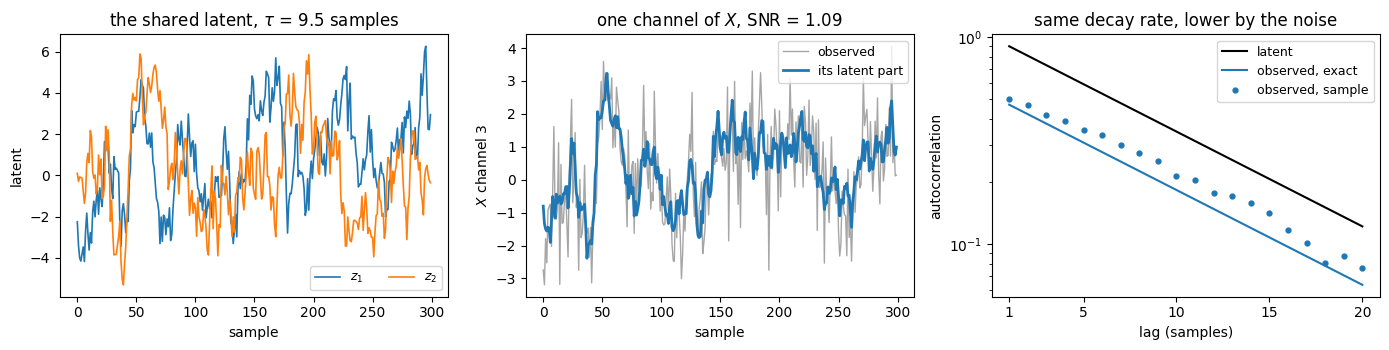

x (10000, 4)   y (10000, 4)   w (10000, 4)
latent timescale tau = 9.49 samples


In [3]:
CFG = dict(dims={'x': 4, 'y': 4, 'w': 4}, d=2, phi=0.9, coupling=0.4,
           noise=1.0, seed=SEED)
oracle = SharedLatentGaussian(**CFG)
sample, latent = oracle.sample(T=T, seed=SEED, return_latents=True)
x = sample['x']
y = sample['y']
w = sample['w']


def offs(name, lo, hi):
    # Offsets lo..hi inclusive, as (variable, offset) pairs.
    return [(name, s) for s in range(lo, hi + 1)]


# Projections are random, so channels of one process differ in how much latent
# they carry. Plot the clearest one and show its latent part separately.
snr = oracle.snr('x')
CH = int(np.argmax(snr))
signal = latent @ oracle.proj['x'].T

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
span = slice(0, min(300, T))

for k in range(oracle.d):
    axes[0].plot(latent[span, k], lw=1.2, label=rf'$z_{k + 1}$')
axes[0].set_xlabel('sample')
axes[0].set_ylabel('latent')
axes[0].set_title(rf'the shared latent, $\tau$ = {oracle.tau:.1f} samples')
axes[0].legend(fontsize=9, ncol=2)

axes[1].plot(x[span, CH], lw=1, color='0.65', label='observed')
axes[1].plot(signal[span, CH], lw=2, color='tab:blue', label='its latent part')
axes[1].set_xlabel('sample')
axes[1].set_ylabel(f'$X$ channel {CH}')
axes[1].set_title(f'one channel of $X$, SNR = {snr[CH]:.2f}')
axes[1].legend(fontsize=9)

lags = np.arange(1, 21)
xc = x[:, CH] - x[:, CH].mean()
empirical = np.array([np.corrcoef(xc[:T - l], xc[l:])[0, 1] for l in lags])
# White observation noise lands entirely at lag 0, so it scales the observed
# curve down by a constant and leaves the decay rate alone.
frac = snr[CH] / (1 + snr[CH])
axes[2].semilogy(lags, oracle.phi ** lags, '-', color='k', lw=1.5, label='latent')
axes[2].semilogy(lags, frac * oracle.phi ** lags, '-', color='tab:blue', lw=1.5,
                 label='observed, exact')
axes[2].semilogy(lags, empirical, 'o', ms=3.5, color='tab:blue',
                 label='observed, sample')
axes[2].set_xticks([1, 5, 10, 15, 20])
axes[2].set_xlabel('lag (samples)')
axes[2].set_ylabel('autocorrelation')
axes[2].set_title('same decay rate, lower by the noise')
axes[2].legend(fontsize=9)

fig.tight_layout()
plt.show()

print(f"x {x.shape}   y {y.shape}   w {w.shape}")
print(f"latent timescale tau = {oracle.tau:.2f} samples")

## 1. Three questions on one dataset

Take the same three signals and ask three different things.

How much does one instant of $X$ say about the matching instant of $Y$? How
much does the recent past of $X$ say about its own present? How much does the
past of $X$ add about the present of $Y$ once $Y$'s own past is accounted for?

Each one is a call to the same estimator with different offsets.

In [4]:
MODEL = nmi.Model(embedding_dim=8, hidden_dim=128, n_layers=2)
TRAIN = nmi.Training(n_epochs=N_EPOCHS, batch_size=256, patience=30,
                     learning_rate=1e-3)
# n_workers is deliberately not in here. Calls that ask for repeats set it to
# N_WORKERS; single estimates leave it at the default of 1.
COMMON = dict(training=TRAIN, split=nmi.Split(mode='blocked'),
              estimator=nmi.Estimator('infonce'), show_progress=False)

opening = [
    ('instantaneous MI', 'I(X[0]; Y[0])',
     oracle.exact([('x', 0)], [('y', 0)]),
     lambda: nmi.instantaneous_mi(x, y, model=MODEL, seed=SEED, **COMMON)),
    ('active information storage', 'I(X[-8..-1]; X[0])',
     oracle.exact(offs('x', -K, -1), [('x', 0)]),
     lambda: nmi.active_information_storage(x, k=K, model=MODEL, seed=SEED, **COMMON)),
    ('transfer entropy', 'I(X[-8..-1]; Y[0] | Y[-8..-1])',
     oracle.exact(offs('x', -K, -1), [('y', 0)], offs('y', -K, -1)),
     lambda: nmi.transfer_entropy(x, y, history_window=K, model=MODEL,
                                  seed=SEED, **COMMON)),
]

print(f"{'quantity':<28} {'offsets':<32} {'exact':>8} {'estimate':>9}")
for name, pattern, exact, call in opening:
    t0 = time.time()
    r = call()
    print(f"{name:<28} {pattern:<32} {float(exact):>8.4f} {r.mi_estimate:>9.4f}"
          f"   ({time.time() - t0:.0f}s)", flush=True)

quantity                     offsets                             exact  estimate


instantaneous MI             I(X[0]; Y[0])                      0.4543    0.5245   (7s)


active information storage   I(X[-8..-1]; X[0])                 0.3281    0.4267   (6s)


transfer entropy             I(X[-8..-1]; Y[0] | Y[-8..-1])     0.0399    0.0969   (12s)


/var/folders/2l/ltx3g97s0xs9n9x3w0z40n4w0000gs/T/ipykernel_54159/2632799718.py:18: UserWarning: TE(X→Y) has an error-amplification factor of 18.1x. It is a small residual (0.0969 bits) of two much larger estimates (I(xy_past;y_future)=0.9257, I(y_past;y_future)=0.8288), so a relative error of eps on each component becomes roughly 18*eps on the result: a 1% component error is about 18% here. Do not read the point estimate on its own. Report the components ('i_xypast_yfuture', 'i_ypast_yfuture') alongside it, check the joint term for ceiling saturation (it is the larger of the two and saturates first, which biases the result toward zero), and prefer more data or more training before concluding that the true value is small.
  lambda: nmi.transfer_entropy(x, y, history_window=K, model=MODEL,


The first number is the largest because $X$ and $Y$ share the latent at the
same instant. The second is smaller. Eight steps of $X$'s own history
recover less about its present than $Y$ does at zero lag, at this coupling and
this observation noise. The third is smallest because most of what $X$'s past
knows about $Y$'s present already sits in $Y$'s past, and conditioning on that
removes it.

The only thing that changed between the three quantities is how we design what
goes inside the estimator.

## 2. What specifies a quantity

Every quantity in the library has the same form,

$$I(A; B \mid C),$$

where $A$, $B$ and $C$ are sets of (variable, offset) pairs and $C$ is empty
for the unconditioned ones. A pair names one signal and one time offset
relative to the instant being predicted, so `('x', -1)` is $X$ one step in the
past and `('y', 0)` is $Y$ right now.

Writing `X[-k..-1]` for $k$ steps of history and `X[0]` for the present, the
quantity notebook 02 estimated was $I(X_0; Y_0)$. The library builds twelve
patterns in all, drawn in the figure.

### The chain rule for conditioning

In practice $I(A; B \mid C)$ is incompatible with the variational neural
estimators as we have them, at least without further assumptions about how the
conditioning is done. They learn a critic that scores pairs of samples, and
there is no place in that machinery to hold a third variable fixed. Getting the
conditional out of them takes a decomposition and the chain rule for mutual
information:

$$\boxed{\;I(A; B \mid C) \;=\; I([A, C]\,;\, B) \;-\; I(C; B)\;}$$

where $[A, C]$ is the concatenation of the two variables. Both terms on the
right are ordinary two-variable mutual informations, so we can still estimate
quantities of the form $I(A; B \mid C)$ with the $I(X;Y)$ formalism we already
have. The library reports the two components as `mi_xw_y` and `mi_w_y`.

$I(C;B)$ is what $C$ alone tells us about $B$. $I([A,C];B)$ is what $C$ and $A$
tell us together. The difference is what $A$ added on top of what $C$ already
carried. Below we see that this is what transfer entropy asks of a signal's
past.


### What the decomposition costs

Every conditional quantity costs two training runs instead of one. The answer
it returns is also a difference, so it inherits the error of both components
while keeping only what survives the subtraction.

**Note:** The difference between $I([A,C];B)$ and $I(C;B)$ can be dominated by
either term, and in that case the result is skewed. We quantify that with the
amplification factor,

$$\text{amp} \;:=\; \frac{\bigl|I([A,C];B)\bigr| \;+\; \bigl|I(C;B)\bigr|}
                        {\bigl|I(A; B \mid C)\bigr|} \;=\; \frac{\bigl|I([A,C];B)\bigr| \;+\; \bigl|I(C;B)\bigr|} {\bigl|I([A,C];B) \;-\; I(C;B)\bigr|}.$$

A relative error $\epsilon$ on each component arrives as roughly
$\text{amp}\cdot\epsilon$ on the result. At $\text{amp}\approx 1$ almost
nothing cancels and the errors pass through undamaged. At $\text{amp}\gtrsim
10$ a small residual is being pulled out of two large and similar numbers, a
one percent component error becomes ten percent or worse, and the sign itself
can flip. Section 4 measures it for every conditional quantity in the library.

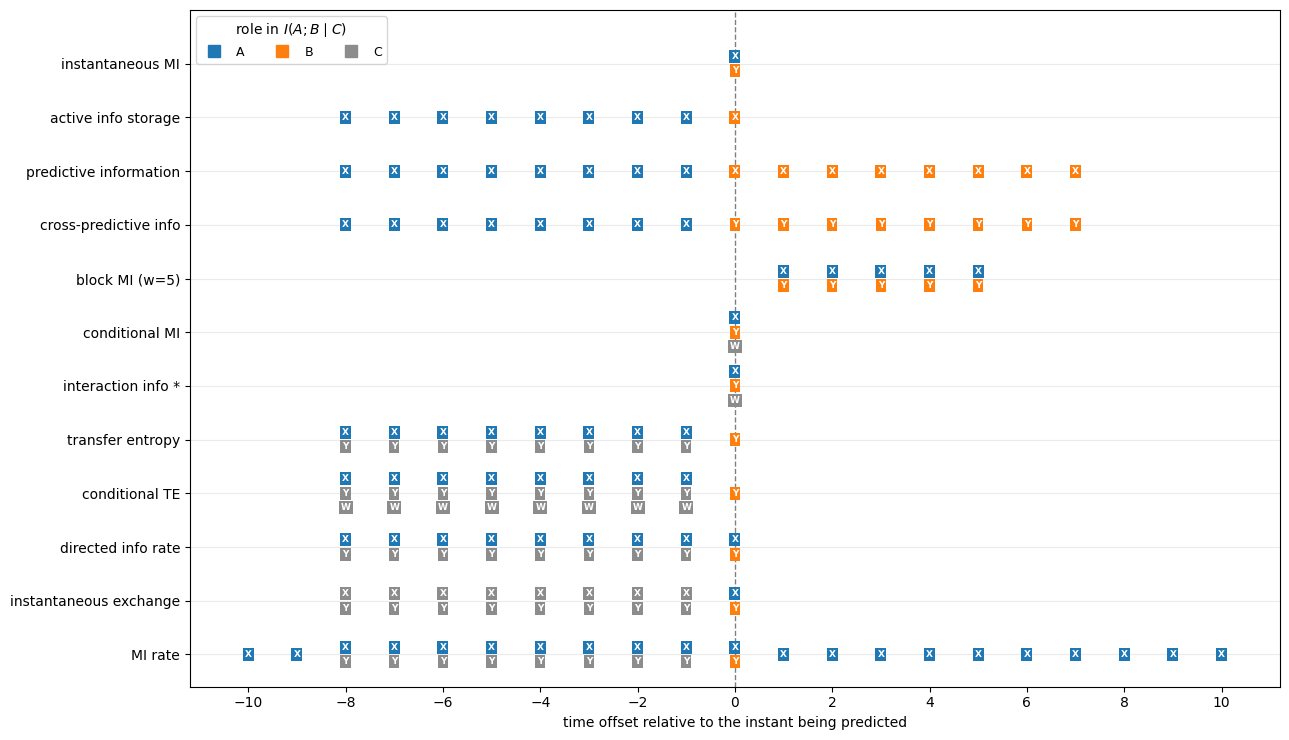

In [5]:
def rng(v, lo, hi):
    # Offsets lo..hi inclusive, for one variable.
    return [(v, o) for o in range(lo, hi + 1)]


PATTERNS = [
    ('instantaneous MI',       [('X', 0)], [('Y', 0)], []),
    ('active info storage',    rng('X', -K, -1), [('X', 0)], []),
    ('predictive information', rng('X', -K, -1), rng('X', 0, K - 1), []),
    ('cross-predictive info',  rng('X', -K, -1), rng('Y', 0, K - 1), []),
    (f'block MI (w={W_BLOCK})', rng('X', 1, W_BLOCK), rng('Y', 1, W_BLOCK), []),
    ('conditional MI',         [('X', 0)], [('Y', 0)], [('W', 0)]),
    ('interaction info *',     [('X', 0)], [('Y', 0)], [('W', 0)]),
    ('transfer entropy',       rng('X', -K, -1), [('Y', 0)], rng('Y', -K, -1)),
    ('conditional TE',         rng('X', -K, -1), [('Y', 0)],
     rng('Y', -K, -1) + rng('W', -K, -1)),
    ('directed info rate',     rng('X', -K, 0), [('Y', 0)], rng('Y', -K, -1)),
    ('instantaneous exchange', [('X', 0)], [('Y', 0)],
     rng('X', -K, -1) + rng('Y', -K, -1)),
    ('MI rate',                rng('X', -HALF_WIDTH, HALF_WIDTH), [('Y', 0)],
     rng('Y', -H_RATE, -1)),
]
ROLE = {'A': 'tab:blue', 'B': 'tab:orange', 'C': '0.55'}

fig, ax = plt.subplots(figsize=(13, 7.5))
for row, (name, A, B, C) in enumerate(PATTERNS):
    ax.axhline(row, color='0.92', lw=0.8, zorder=0)
    # Several pairs can land on one offset, so stack whatever shares a column.
    stacks = {}
    for role, pairs in (('A', A), ('B', B), ('C', C)):
        for var, off in pairs:
            stacks.setdefault(off, []).append((role, var))
    for off, stack in stacks.items():
        for j, (role, var) in enumerate(stack):
            dy = (j - (len(stack) - 1) / 2) * 0.27
            ax.text(off, row + dy, var, ha='center', va='center', fontsize=6.5,
                    color='white', fontweight='bold', zorder=3,
                    bbox=dict(boxstyle='square,pad=0.22', fc=ROLE[role], ec='none'))

ax.axvline(0, color='k', lw=1, ls='--', alpha=0.5, zorder=1)
ax.set_yticks(range(len(PATTERNS)))
ax.set_yticklabels([p[0] for p in PATTERNS])
ax.invert_yaxis()
ax.set_xlim(-HALF_WIDTH - 1.2, HALF_WIDTH + 1.2)
ax.set_xticks(range(-HALF_WIDTH, HALF_WIDTH + 1, 2))
ax.set_ylim(len(PATTERNS) - 0.4, -1.0)
ax.set_xlabel('time offset relative to the instant being predicted')
handles = [plt.Line2D([], [], marker='s', ls='', ms=9, color=ROLE[r], label=r)
           for r in ('A', 'B', 'C')]
ax.legend(handles=handles, loc='upper left', ncol=3, fontsize=9,
          title='role in $I(A; B \\mid C)$')
fig.tight_layout()
plt.show()

Read each row for its units and its cost:

- **The units.** How many offsets $B$ spans decides whether the answer is per
step or extensive over a block. Instantaneous MI has one offset in $B$ and
comes back per observation. Block MI has five and comes back per window of
five. Section 3 covers that in more detail.

- **The cost.** An empty $C$ is one training run. A non-empty $C$ is the
difference from section 2, so it costs two runs and inherits error from both.
Six of the twelve are in that group, and section 4 shows what it does to them.

Arity (the number of arguments or operands taken by a function, operation or
relation) is one for active information storage, two for transfer entropy, and
three for conditional MI. It is separate from the number of offset groups.
Transfer entropy names two signals and uses three offset groups,
$X_\text{past}, Y_\text{past}, Y_0$.

Interaction information carries the asterisk because it is the one row that is
not a plain $I(A;B\mid C)$. The library computes it as $I([X,W];Y) - I(X;Y) -
I(W;Y)$, which rearranges to $I(X;Y \mid W) - I(X;Y)$, so it draws on the same
offsets as conditional MI and then subtracts the unconditioned term as well. A
positive value means the two sources are synergistic about $Y$ and a negative
one means they are redundant.

The names are a convenience over the offsets and they are used inconsistently
across the literature. Two papers can use one name for two different offset
patterns, so the pattern is what to check.

## 3. The units come from the offsets

Moving from the iid world into time adds several
levels of complexity. The first is that we sometimes need to observe $X$ or $Y$
over a window of time to see the full extent of a phenomenon. The simplest
thing to do is take a window of $w$ samples and compute the MI from that. A
window of $w$ samples is a bigger question than one instant, so it comes back
with a bigger answer. Naive windowing and reporting whatever comes out is
tricky. We'll see this from the oracle first and then from our estimator.

In [6]:
exact_block = {wn: float(oracle.block_mi(wn)) for wn in WINDOW_SWEEP}

print(f"{'w':>3} {'exact I_w':>10} {'I_w / w':>10}")
for wn in WINDOW_SWEEP:
    print(f"{wn:>3} {exact_block[wn]:>10.4f} {exact_block[wn] / wn:>10.4f}")

  w  exact I_w    I_w / w
  1     0.4543     0.4543
  2     0.8148     0.4074
  3     1.1157     0.3719
  5     1.6608     0.3322
 10     2.9604     0.2960
 20     5.5360     0.2768
 30     8.1106     0.2704


The exact $I_w$ grows with the window size $w$ while $I_w/w$, the per-sample version, never settles and falls across this range.

We shouldn't report block MI without its window size, and dividing by the
duration does not repair that. What the division misses is an offset. Block MI
behaves as $I_w = \bar{I}w + b$ with a real nonzero $b$, so dividing leaves a residual $b/w$ that moves with whichever window you happened to pick.

Running the estimate at several $(w, I_w)$ and fitting a straight line recovers
both the offset $b$ and the MI rate $\bar{I}$.
The offset $b$ is the subextensive part of the block MI. A single process has an analogous constant, its excess entropy. The two share a shape without being the same quantity, so do not identify one with the other.
Estimating the same curve also shows a second effect, inherited from the
architecture of neural estimators.

In [7]:
t0 = time.time()
block_rows = []
for wn in WINDOW_SWEEP:
    # One call per window, N_SEEDS repeats inside it. The exact value and the
    # ceiling are per window, so the window stays a loop and the repeats do not.
    r = nmi.block_mi(x, y, window_size=wn, sweep_grid={'run_id': list(range(N_SEEDS))},
                     model=MODEL, n_workers=N_WORKERS, seed=SEED, **COMMON)
    ests = r.runs['mi'].to_numpy()               # one value per repeat
    b = dict(w=wn, exact=exact_block[wn], est=float(ests.mean()),
             sd=float(ests.std(ddof=1)),
             ceiling=float(r.runs['train_ceiling_mi'].mean()))
    b['saturation'] = b['exact'] / b['ceiling']
    block_rows.append(b)
    print(f"w={wn:>3}  exact={b['exact']:>7.4f}  est={b['est']:>7.4f} "
          f"+/- {b['sd']:.4f}  ratio={b['est'] / b['exact']:.3f}  "
          f"ceiling={b['ceiling']:>5.2f}  exact/ceiling={b['saturation']:.2f}",
          flush=True)
print(f"({time.time() - t0:.0f}s)")

w=  1  exact= 0.4543  est= 0.5094 +/- 0.0139  ratio=1.121  ceiling=12.29  exact/ceiling=0.04


w=  2  exact= 0.8148  est= 0.9059 +/- 0.0143  ratio=1.112  ceiling=11.97  exact/ceiling=0.07


w=  3  exact= 1.1157  est= 1.2053 +/- 0.0357  ratio=1.080  ceiling=11.38  exact/ceiling=0.10


w=  5  exact= 1.6608  est= 1.6832 +/- 0.0898  ratio=1.014  ceiling=10.65  exact/ceiling=0.16


w= 10  exact= 2.9604  est= 2.8058 +/- 0.0490  ratio=0.948  ceiling= 9.65  exact/ceiling=0.31


w= 20  exact= 5.5360  est= 4.3377 +/- 0.1293  ratio=0.784  ceiling= 8.69  exact/ceiling=0.64


w= 30  exact= 8.1106  est= 4.5066 +/- 0.6874  ratio=0.556  ceiling= 8.08  exact/ceiling=1.00


(68s)


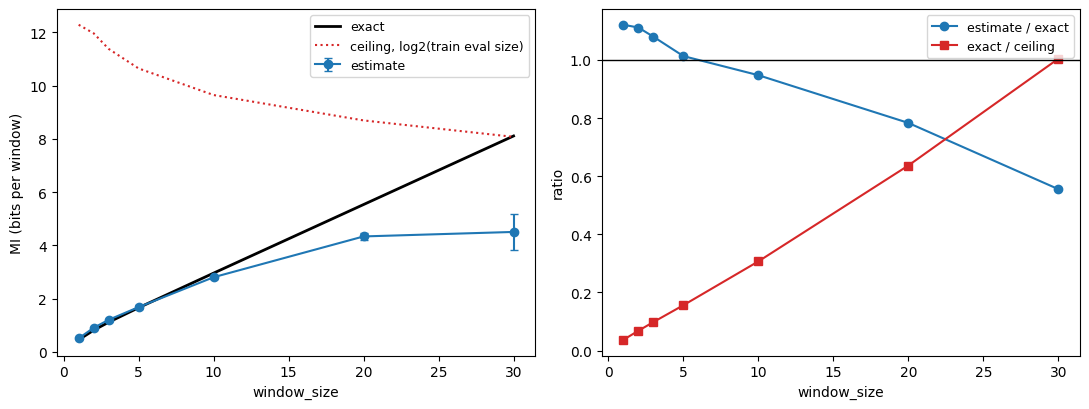

In [8]:
ws = [b['w'] for b in block_rows]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].plot(ws, [b['exact'] for b in block_rows], 'k-', lw=2, label='exact')
axes[0].errorbar(ws, [b['est'] for b in block_rows],
                 yerr=[b['sd'] for b in block_rows], fmt='o-', capsize=3,
                 label='estimate')
axes[0].plot(ws, [b['ceiling'] for b in block_rows], ':', color='tab:red',
             label='ceiling, log2(train eval size)')
axes[0].set_xlabel('window_size')
axes[0].set_ylabel('MI (bits per window)')
axes[0].legend(fontsize=9)

axes[1].plot(ws, [b['est'] / b['exact'] for b in block_rows], 'o-',
             color='tab:blue', label='estimate / exact')
axes[1].plot(ws, [b['saturation'] for b in block_rows], 's-',
             color='tab:red', label='exact / ceiling')
axes[1].axhline(1.0, color='k', lw=1)
axes[1].set_xlabel('window_size')
axes[1].set_ylabel('ratio')
axes[1].legend(fontsize=9)

fig.tight_layout()
plt.show()

- **Left:** The estimate tracks the exact value while there is room and then peels away.
- **Right:** The estimate falls as the saturation climbs until the two cross near the largest windows.

Windows of $w$ drawn from one recording leave about $1/w$ as many evaluation
samples, and the ceiling comes down about a bit per doubling once the window
count drops below the evaluation cap. The truth is climbing at the same time,
so the two close on each other and the estimate degrades where they meet.

**Note:** The result above is for *non-overlapping* windows. Overlapping windows could in principle buy some headroom at the larger window sizes, but they are correlated with the existing ones and add no new information. The most they buy is more gradient steps for the optimiser, and gentler training buys the same. Notebook 04 returns to this.

### The rate is a slope

The intensive quantity, bits per sample, is the slope of the extensive
curve. Reading that slope off estimates of $I_w$ at large $w$ walks into the
ceiling we just watched, so we estimate the slope directly instead.

The chain rule for mutual information splits the block into one term per step
of $Y$,

$$I\bigl(X_1^w;\, Y_1^w\bigr) \;=\; \sum_{t=1}^{w} I\bigl(X_1^w;\; Y_t \,\bigm|\, Y_1^{t-1}\bigr),$$

and stationarity makes every term the same quantity once $t$ is past the
transient, so the block is $w$ copies of one number plus edge effects. That
gives us the rate as:

$$\bar{I} \;=\; \lim_{t \to \infty} I\bigl(X;\, Y_t \bigm| Y_1^{t-1}\bigr)
   \;\approx\; I\bigl(X_{-L}^{+L};\; Y_0 \bigm| Y_{-h}^{-1}\bigr).$$

`mi_rate(x, y, h, half_width)` estimates that directly, with the half-width $L$
set by `half_width`. $X$ enters as a two-sided
window because the terms in the sum see $X$ on both sides of $Y_t$. The history
$h$ has to run long enough to hold $Y$'s own dependence.

This is the general move for anything extensive. A block quantity grows without
bound and eventually crosses the estimator's $\log_2 K$ ceiling. Its per-step
increment stays the same size at every window length, so estimating the
increment and multiplying back keeps the whole calculation far below the
ceiling. We can also measure the slope of the exact curve from the oracle and
compare the two.

In [9]:
big = [wn for wn in WINDOW_SWEEP if wn >= 5]
A_fit = np.vstack([np.array(big, dtype=float), np.ones(len(big))]).T
slope, intercept = np.linalg.lstsq(
    A_fit, np.array([exact_block[wn] for wn in big]), rcond=None)[0]

exact_rate = float(oracle.exact(offs('x', -HALF_WIDTH, HALF_WIDTH), [('y', 0)],
                                offs('y', -H_RATE, -1)))

print(f"slope of the exact curve (w >= {big[0]}) : {slope:>8.4f} bits per sample")
print(f"intercept                          : {intercept:>+8.4f} bits")
print(f"exact mi_rate, L={HALF_WIDTH} h={H_RATE}              : {exact_rate:>8.4f} bits per sample")
print()
print("dividing the window out, at each w:")
for wn in WINDOW_SWEEP:
    print(f"    w={wn:>3}  {exact_block[wn] / wn:.4f}")

slope of the exact curve (w >= 5) :   0.2579 bits per sample
intercept                          :  +0.3764 bits
exact mi_rate, L=10 h=8              :   0.2574 bits per sample

dividing the window out, at each w:
    w=  1  0.4543
    w=  2  0.4074
    w=  3  0.3719
    w=  5  0.3322
    w= 10  0.2960
    w= 20  0.2768
    w= 30  0.2704


In [10]:
# mi_rate uses different window lengths in A and C, so it routes through a
# dual-branch model.
DUAL = nmi.Model(embedding_model='dual_branch', embedding_dim=8,
                 hidden_dim=128, n_layers=2)

t0 = time.time()
rate = nmi.mi_rate(x, y, h=H_RATE, half_width=HALF_WIDTH, model=DUAL, seed=SEED, **COMMON)
print(f"estimated mi_rate : {rate.mi_estimate:.4f} bits per sample")
print(f"exact             : {exact_rate:.4f}")
print(f"ratio             : {rate.mi_estimate / exact_rate:.3f}")
print(f"({time.time() - t0:.0f}s)")

estimated mi_rate : 0.2648 bits per sample
exact             : 0.2574
ratio             : 1.029
(58s)


In [11]:
worst = block_rows[-1]
print("what each route asks the estimator for:")
print(f"  block MI at w={worst['w']:<3}: {worst['exact']:.2f} bits against a "
      f"ceiling of {worst['ceiling']:.2f}, and the estimate recovers "
      f"{worst['est'] / worst['exact']:.2f} of it")
print(f"  mi_rate{'':<11}: {exact_rate:.2f} bits, a target "
      f"{worst['exact'] / exact_rate:.0f}x smaller, and the estimate recovers "
      f"{rate.mi_estimate / exact_rate:.2f} of it")

what each route asks the estimator for:
  block MI at w=30 : 8.11 bits against a ceiling of 8.08, and the estimate recovers 0.56 of it
  mi_rate           : 0.26 bits, a target 32x smaller, and the estimate recovers 1.03 of it


The slope and `mi_rate` agree with each other. The naive division earlier
disagrees with both by a different amount at every window, as the intercept is
still sitting inside the number.

The two routes measure the same system two ways and should in principle agree. However, the block
at the largest window asks for almost the whole ceiling and recovers only about
half of it. On the other hand, the rate asks a far smaller question of the same recording and
gets the answer back intact.

**Note:** A per-sample quantity becomes bits per second by dividing by the bin width.

In [12]:
for bin_ms in (1, 20, 100):
    print(f"at a {bin_ms:>3} ms bin: {exact_rate / (bin_ms / 1000):>8.2f} bits per second")

at a   1 ms bin:   257.41 bits per second
at a  20 ms bin:    12.87 bits per second
at a 100 ms bin:     2.57 bits per second


The same information rate is a different number of bits per second at every bin
width, so you cannot read a rate without knowing its bin width either. On real
recordings the bin width is usually either set by the experiment's resolution or chosen by someone upstream of you.

## 4. Measuring all twelve against their exact values

The library currently supports the estimation of twelve quantities, each one a
choice of the offsets and of what goes in $A$, $B$ and $C$. Here we test them
against the exact value for that pattern using the analytic solution, three
seeds each.

Once $C \neq \emptyset$ we have the difference from section 2, so the table
reports the amplification factor next to the seed spread.

In [13]:
x_past, y_past, w_past = offs('x', -K, -1), offs('y', -K, -1), offs('w', -K, -1)
x_now, y_now, w_now = [('x', 0)], [('y', 0)], [('w', 0)]

ii_exact = (oracle.exact(x_now + w_now, y_now) - oracle.exact(x_now, y_now)
            - oracle.exact(w_now, y_now))

REPEATS = dict(sweep_grid={'run_id': list(range(N_SEEDS))}, n_workers=N_WORKERS,
               seed=SEED, **COMMON)

QUANTITIES = [
    ('active information storage', oracle.exact(x_past, x_now),
     lambda: nmi.active_information_storage(x, k=K, model=MODEL, **REPEATS)),
    ('predictive information', oracle.exact(x_past, offs('x', 0, K - 1)),
     lambda: nmi.predictive_information(x, k=K, model=MODEL, **REPEATS)),
    ('instantaneous MI', oracle.exact(x_now, y_now),
     lambda: nmi.instantaneous_mi(x, y, model=MODEL, **REPEATS)),
    ('cross-predictive information', oracle.exact(x_past, offs('y', 0, K - 1)),
     lambda: nmi.cross_predictive_information(x, y, k=K,
                                              model=MODEL, **REPEATS)),
    (f'block MI (w={W_BLOCK})', oracle.block_mi(W_BLOCK),
     lambda: nmi.block_mi(x, y, window_size=W_BLOCK, model=MODEL, **REPEATS)),
    ('conditional MI', oracle.exact(x_now, y_now, w_now),
     lambda: nmi.run(x, y, mode='conditional', conditional=Conditional(w_data=w),
                     model=MODEL, **REPEATS)),
    ('transfer entropy', oracle.exact(x_past, y_now, y_past),
     lambda: nmi.transfer_entropy(x, y, history_window=K, model=MODEL, **REPEATS)),
    ('conditional TE', oracle.exact(x_past, y_now, y_past + w_past),
     lambda: nmi.conditional_transfer_entropy(x, y, w, history_window=K,
                                              model=MODEL, **REPEATS)),
    ('MI rate', exact_rate,
     lambda: nmi.mi_rate(x, y, h=H_RATE, half_width=HALF_WIDTH, model=DUAL, **REPEATS)),
    ('instantaneous exchange', oracle.exact(x_now, y_now, x_past + y_past),
     lambda: nmi.instantaneous_exchange(x, y, k=K, model=DUAL, **REPEATS)),
    ('directed information rate', oracle.exact(offs('x', -K, 0), y_now, y_past),
     lambda: nmi.directed_information_rate(x, y, k=K, model=DUAL, **REPEATS)),
    ('interaction information', ii_exact,
     lambda: nmi.interaction_information(x, y, w, model=MODEL, **REPEATS)),
]


def read(result):
    # Every quantity returns one row here, with the mean and spread over its
    # repeats. The ones built by subtraction also carry their amplification factor.
    row = result.dataframe.iloc[0]
    return (float(row['mi_mean']), float(row['mi_std']),
            row.get('amplification_factor'))


t_all = time.time()
taxonomy = []
for name, exact, call in QUANTITIES:
    t0 = time.time()
    m, s, amp = read(call())
    taxonomy.append(dict(name=name, exact=float(exact), est=m, sd=s,
                         err=100 * (m - float(exact)) / abs(float(exact)),
                         amp=amp, rel_spread=100 * s / abs(m)))
    t = taxonomy[-1]
    print(f"{name:<30} exact={t['exact']:+.4f}  est={t['est']:+.4f}  "
          f"err={t['err']:+6.1f}%  spread={t['rel_spread']:5.1f}%  "
          f"({time.time() - t0:.0f}s)", flush=True)
print(f"total {time.time() - t_all:.0f}s")

active information storage     exact=+0.3281  est=+0.4265  err= +30.0%  spread=  5.3%  (13s)


predictive information         exact=+0.5059  est=+0.6792  err= +34.2%  spread=  4.7%  (13s)


instantaneous MI               exact=+0.4543  est=+0.5094  err= +12.1%  spread=  2.7%  (14s)


cross-predictive information   exact=+0.6606  est=+0.8226  err= +24.5%  spread=  3.0%  (13s)


block MI (w=5)                 exact=+1.6608  est=+1.6832  err=  +1.4%  spread=  5.3%  (9s)


...

/var/folders/2l/ltx3g97s0xs9n9x3w0z40n4w0000gs/T/ipykernel_54159/3479278102.py:33: UserWarning: Conditional MI (dual-branch) has an error-amplification factor of 14.3x. It is a small residual (0.1235 bits) of two much larger estimates (I(XC;Y)=0.9463, I(C;Y)=0.8228), so a relative error of eps on each component becomes roughly 14*eps on the result: a 1% component error is about 14% here. Do not read the point estimate on its own. Report the components ('mi_xw_y', 'mi_w_y') alongside it, check the joint term for ceiling saturation (it is the larger of the two and saturates first, which biases the result toward zero), and prefer more data or more training before concluding that the true value is small.
  lambda: nmi.instantaneous_exchange(x, y, k=K, model=DUAL, **REPEATS)),


directed information rate      exact=+0.1564  est=+0.1605  err=  +2.6%  spread=  4.3%  (57s)


/var/folders/2l/ltx3g97s0xs9n9x3w0z40n4w0000gs/T/ipykernel_54159/3479278102.py:35: UserWarning: Conditional MI (dual-branch) has an error-amplification factor of 10.7x. It is a small residual (0.1605 bits) of two much larger estimates (I(XC;Y)=0.9358, I(C;Y)=0.7753), so a relative error of eps on each component becomes roughly 11*eps on the result: a 1% component error is about 11% here. Do not read the point estimate on its own. Report the components ('mi_xw_y', 'mi_w_y') alongside it, check the joint term for ceiling saturation (it is the larger of the two and saturates first, which biases the result toward zero), and prefer more data or more training before concluding that the true value is small.
  lambda: nmi.directed_information_rate(x, y, k=K, model=DUAL, **REPEATS)),


interaction information        exact=-0.1690  est=-0.1893  err= -12.0%  spread= 14.1%  (42s)


total 368s


In [14]:
print(f"{'quantity':<30} {'exact':>8} {'est':>8} {'err':>8} {'amp':>7} {'spread':>8}")
print("-" * 74)
for t in taxonomy:
    amp = '' if t['amp'] is None else f"{t['amp']:.1f}"
    print(f"{t['name']:<30} {t['exact']:>+8.4f} {t['est']:>+8.4f} "
          f"{t['err']:>+7.1f}% {amp:>7} {t['rel_spread']:>7.1f}%")

quantity                          exact      est      err     amp   spread
--------------------------------------------------------------------------
active information storage      +0.3281  +0.4265   +30.0%             5.3%
predictive information          +0.5059  +0.6792   +34.2%             4.7%
instantaneous MI                +0.4543  +0.5094   +12.1%             2.7%
cross-predictive information    +0.6606  +0.8226   +24.5%             3.0%
block MI (w=5)                  +1.6608  +1.6832    +1.4%             5.3%
conditional MI                  +0.2854  +0.3201   +12.2%     3.6     6.1%
transfer entropy                +0.0399  +0.0664   +66.3%    25.7    80.8%
conditional TE                  +0.0256  +0.0394   +53.9%    46.4    78.0%
MI rate                         +0.2574  +0.2383    -7.4%     7.5    10.0%
instantaneous exchange          +0.1165  +0.1235    +6.0%    14.3    14.1%
directed information rate       +0.1564  +0.1605    +2.6%    10.7     4.3%
interaction information  

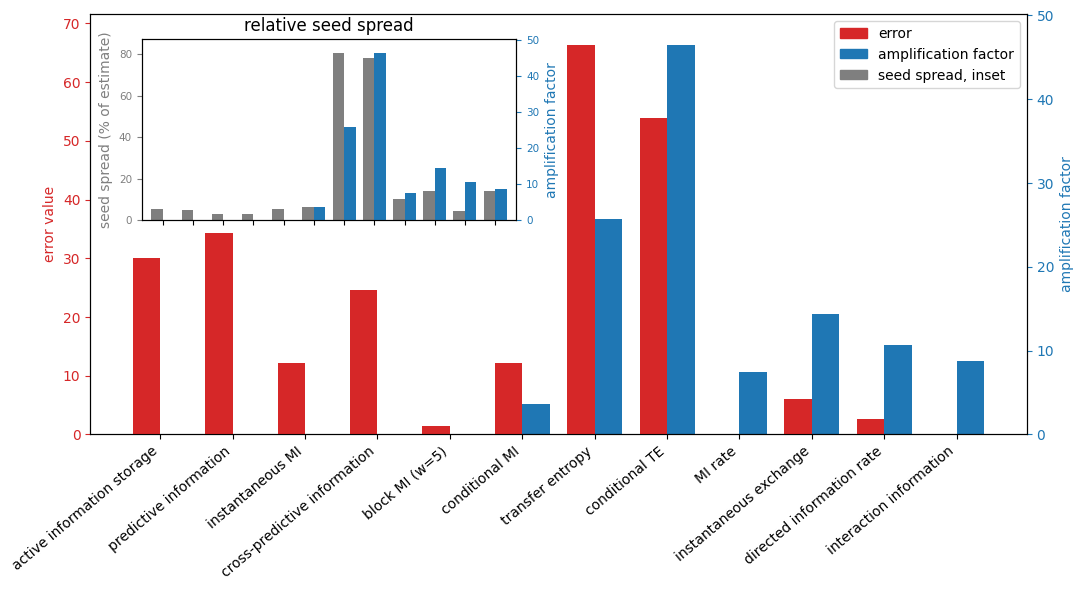

In [15]:
names = [t['name'] for t in taxonomy] 
errs = np.array([t['err'] for t in taxonomy]) 
spreads = np.array([t['rel_spread'] for t in taxonomy]) 
amps = np.array([np.nan if t['amp'] is None else t['amp'] for t in taxonomy]) 
pos = np.arange(len(names)) 
WIDTH, ZOOM = 0.38, 15.0 

ERR_TOP = errs.max() * 1.08 
AMP_TOP = np.nanmax(amps) * 1.08 
SPREAD_TOP = spreads.max() * 1.08 

fig, ax = plt.subplots(figsize=(11, 6)) 
ax_amp = ax.twinx() 

ax.bar(pos - WIDTH / 2, errs, WIDTH, color='tab:red') 
ax_amp.bar(pos + WIDTH / 2, np.nan_to_num(amps), WIDTH, color='tab:blue') 

ax.set_ylim(0, ERR_TOP) 
ax_amp.set_ylim(0, AMP_TOP) 
ax.set_ylabel('error value', color='tab:red') 
ax_amp.set_ylabel('amplification factor', color='tab:blue') 
ax.tick_params(axis='y', colors='tab:red') 
ax_amp.tick_params(axis='y', colors='tab:blue') 
ax.set_xticks(pos) 
ax.set_xticklabels(names, rotation=40, ha='right') 
ax.set_zorder(ax_amp.get_zorder() + 1) 
ax.patch.set_visible(False) 

ax.legend(handles=[Patch(color='tab:red', label='error'), 
                   Patch(color='tab:blue', label='amplification factor'), 
                   Patch(color='tab:grey', label='seed spread, inset')], loc='upper right') 
fig.tight_layout() 

inset = ax.inset_axes([0.055, 0.51, 0.40, 0.43])
inset_amp = inset.twinx()

inset.bar(pos - WIDTH / 2, spreads, WIDTH, color='tab:grey') 
inset_amp.bar(pos + WIDTH / 2, np.nan_to_num(amps), WIDTH, color='tab:blue')

inset.set_ylim(0, SPREAD_TOP) 
inset_amp.set_ylim(0, AMP_TOP)
inset.tick_params(axis='y', labelsize=7.5, colors='tab:grey') 
inset_amp.tick_params(axis='y', labelsize=7.5, colors='tab:blue')
inset.set_ylabel('seed spread (% of estimate)', color='tab:grey') 
inset_amp.set_ylabel('amplification factor', color='tab:blue')
inset.set_xlim(-0.7, len(names) - 0.3) 
inset.set_xticks(pos) 
inset.set_xticklabels([]) 
inset.set_zorder(inset_amp.get_zorder() + 1)
inset.patch.set_visible(False)
inset.set_title('relative seed spread') 

plt.show()

Quantities with an empty $C$ are a single estimate, so they have no
amplification factor. They can still be wrong in the ways any single estimate
can, and none of their error comes from a subtraction, where the errors of both
components enter the result. A high
amplification factor (blue) doesn't necessarily mean a higher absolute error
(red), but it usually tracks the spread across seeds (grey, inset).

That correspondence is useful because the two are priced differently. The amplification
factor comes out of a single run. The spread costs one run per seed. Reading the
amplification factor first tells you which quantities are going to be hard on
your data before you spend the repeats confirming it.

Transfer entropy and conditional transfer entropy are where both diagnostics
break. Each is off by more than half its own value, with a spread across
seeds of a similar size, so this run resolves little more than their sign. Both hold the smallest exact values in
the table and carry the largest amplification factors, so each is a small
residual pulled out of two much larger estimates.

Numbers like these tell you to collect more data,
to ask a coarser question, or to hold off trusting what you have until
something else confirms it.

## Where this goes next

The full catalogue of quantities, with the offset pattern the library builds
for each one, is in `reference/THEORY.md`.

Notebook 04 asks what your data does to the estimate once the sample axis is
time. This is where windowing and the split start to matter.